# 中芯国际 (00981.HK) 技术指标分析

本 Notebook 基于中芯国际港股历史日线数据，逐步计算并可视化 **RSI、MACD、布林带、ATR** 四个常用技术指标。

> 数据来源: 东方财富 API  
> 时间范围: 2020-01-02 至 2026-07-03  
> 股票代码: 00981.HK（中芯国际 / SMIC）

## Cell 1: 环境准备与数据获取

In [1]:
# 导入依赖库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
import urllib.request
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 通过东方财富 API 获取中芯国际港股日线数据
url = (
    'https://push2his.eastmoney.com/api/qt/stock/kline/get?'
    'secid=116.00981&fields1=f1,f2,f3,f4,f5,f6&'
    'fields2=f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61&'
    'klt=101&fqt=1&beg=20200101&end=20260703&lmt=2000'
)
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req, timeout=30) as resp:
    raw = json.loads(resp.read().decode())

klines = raw['data']['klines']
print(f'股票名称: {raw["data"]["name"]} ({raw["data"]["code"]})')
print(f'获取到 {len(klines)} 条交易数据')

# 解析数据为 DataFrame
rows = []
for k in klines:
    parts = k.split(',')
    rows.append({
        'trade_date': parts[0],
        'open': float(parts[1]),
        'close': float(parts[2]),
        'high': float(parts[3]),
        'low': float(parts[4]),
        'vol': int(parts[5]),
        'amount': float(parts[6]),
        'amplitude': float(parts[7]),
        'pct_chg': float(parts[8]),
        'change': float(parts[9]),
        'turnover': float(parts[10]),
    })

df = pd.DataFrame(rows)
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.sort_values('trade_date').reset_index(drop=True)

# 检查数据
print(f'\n数据形状: {df.shape}')
print(f'日期范围: {df["trade_date"].min().date()} ~ {df["trade_date"].max().date()}')
print(f'\n缺失值检查:')
print(df.isnull().sum())
print(f'\n前5行数据:')
df.head()

D:\Anaconda\lib\site-packages\ipykernel\parentpoller.py:116: UserWarning: Parent poll failed.  If the frontend dies,
                the kernel may be left running.  Please let us know
                about your system (bitness, Python, etc.) at
                ipython-dev@scipy.org
  ipython-dev@scipy.org""")


股票名称: 中芯国际 (00981)
获取到 1597 条交易数据

数据形状: (1597, 11)
日期范围: 2020-01-02 ~ 2026-07-03

缺失值检查:
trade_date    0
open          0
close         0
high          0
low           0
vol           0
amount        0
amplitude     0
pct_chg       0
change        0
turnover      0
dtype: int64

前5行数据:


,trade_date,open,close,high,low,vol,amount,amplitude,pct_chg,change,turnover
0,2020-01-02,11.94,12.70,12.78,11.94,113010310,1.414525e+09,7.04,6.37,0.76,2.23
1,2020-01-03,12.84,12.64,13.04,12.50,63114482,8.042193e+08,4.25,-0.47,-0.06,1.25
2,2020-01-06,12.60,13.04,13.30,12.54,101621920,1.324644e+09,6.01,3.16,0.40,2.01
3,2020-01-07,13.04,12.60,13.08,12.44,70943866,9.011288e+08,4.91,-3.37,-0.44,1.40
4,2020-01-08,12.42,12.72,12.96,12.40,48493079,6.191483e+08,4.44,0.95,0.12,0.96


## Cell 2: 数据概览与基础统计

=== 收盘价描述性统计 ===
count    1597.000000
mean       29.119674
std        18.446393
min        11.380000
25%        17.100000
50%        21.350000
75%        29.100000
max        91.050000
Name: close, dtype: float64


D:\Anaconda\lib\site-packages\matplotlib\cbook\__init__.py:2064: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
D:\Anaconda\lib\site-packages\matplotlib\axes\_base.py:248: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
D:\Anaconda\lib\site-packages\matplotlib\axes\_base.py:250: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


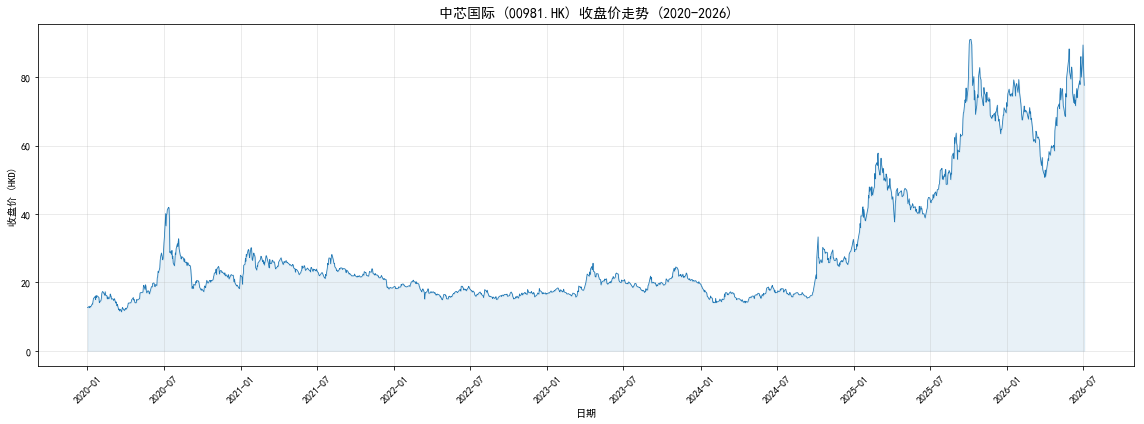


=== 年度统计 ===


,交易日数,年均收盘价,最高价,最低价,年化波动率
year,,,,,
2020,248,20.20,44.80,11.18,78.58
2021,247,23.89,31.95,17.92,48.54
2022,246,17.10,20.95,14.64,40.32
2023,243,19.80,25.75,15.70,43.64
2024,246,19.09,35.50,13.88,64.35
2025,246,54.47,93.50,28.35,61.66
2026,121,70.08,93.00,49.32,59.13


In [2]:
# 描述性统计
print('=== 收盘价描述性统计 ===')
print(df['close'].describe())

# 收盘价趋势图
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['trade_date'], df['close'], color='#1f77b4', linewidth=0.8)
ax.set_title('中芯国际 (00981.HK) 收盘价走势 (2020-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('日期')
ax.set_ylabel('收盘价 (HKD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)
ax.fill_between(df['trade_date'], df['close'], alpha=0.1, color='#1f77b4')
plt.tight_layout()
plt.show()

# 年度统计
df['year'] = df['trade_date'].dt.year
yearly = df.groupby('year').agg(
    交易日数=('close', 'count'),
    年均收盘价=('close', 'mean'),
    最高价=('high', 'max'),
    最低价=('low', 'min'),
    年化波动率=('pct_chg', 'std')
).round(2)
yearly['年化波动率'] = (yearly['年化波动率'] * np.sqrt(250)).round(2)
print('\n=== 年度统计 ===')
yearly

## Cell 3: RSI 指标 — 计算与可视化

### 计算步骤
1. 计算每日价格变动 Δ = Close[t] - Close[t-1]
2. 拆分涨跌: gain = max(Δ, 0), loss = max(-Δ, 0)
3. 计算 14 日平均涨幅 avg_gain 和平均跌幅 avg_loss（Wilder 平滑法）
4. 计算 RS = avg_gain / avg_loss
5. 计算 RSI = 100 - 100 / (1 + RS)

=== RSI 计算中间结果（前20行有效数据）===


,trade_date,close,delta,gain,loss,avg_gain,avg_loss,rsi
14,2020-01-22,16.10,1.10,1.10,0.00,0.3471,0.1043,76.8987
15,2020-01-23,15.50,-0.60,0.00,0.60,0.3223,0.1397,69.7659
16,2020-01-24,16.14,0.64,0.64,0.00,0.3450,0.1297,72.6772
17,2020-01-29,15.62,-0.52,0.00,0.52,0.3204,0.1576,67.0296
18,2020-01-30,14.08,-1.54,0.00,1.54,0.2975,0.2563,53.7167
19,2020-01-31,14.30,0.22,0.22,0.00,0.2920,0.2380,55.0890
20,2020-02-03,14.72,0.42,0.42,0.00,0.3011,0.2210,57.6694
21,2020-02-04,15.48,0.76,0.76,0.00,0.3339,0.2052,61.9317
22,2020-02-05,16.80,1.32,1.32,0.00,0.4043,0.1906,67.9651
23,2020-02-06,17.18,0.38,0.38,0.00,0.4026,0.1770,69.4654



当前 RSI(14): 48.97
状态: 中性区域 (30-70)


D:\Anaconda\lib\site-packages\matplotlib\cbook\__init__.py:2064: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
D:\Anaconda\lib\site-packages\matplotlib\axes\_base.py:248: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
D:\Anaconda\lib\site-packages\matplotlib\axes\_base.py:250: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


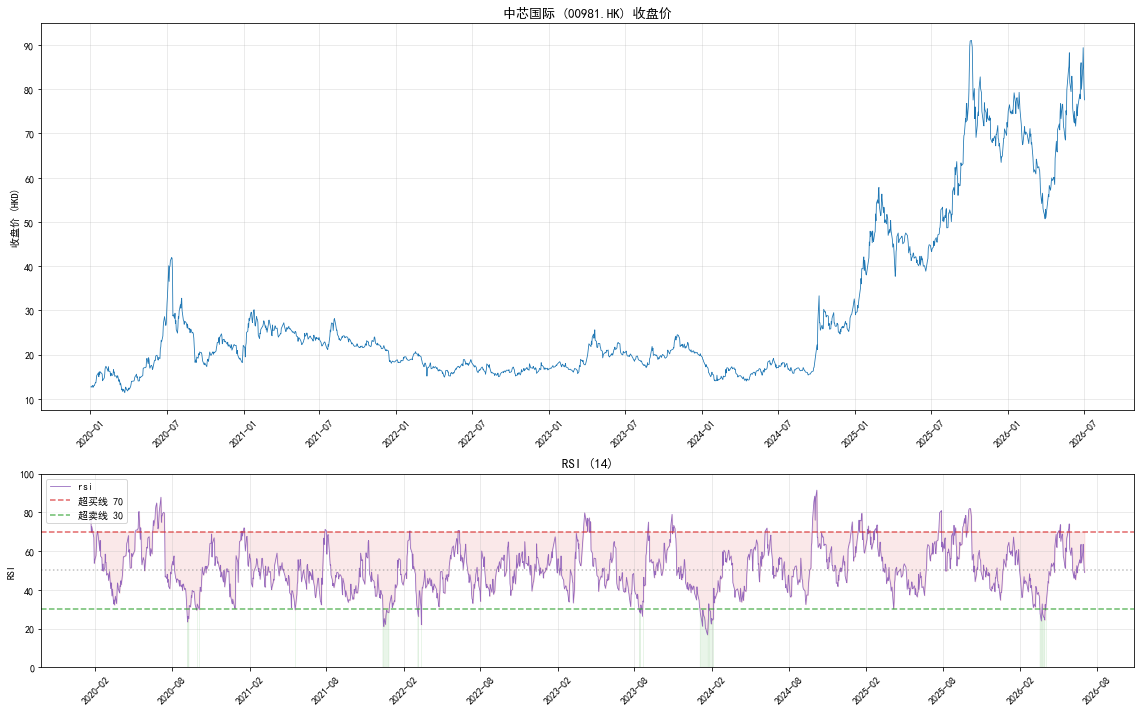

In [3]:
# RSI 参数
RSI_PERIOD = 14

# Step 1: 计算价格变动
df['delta'] = df['close'].diff()

# Step 2: 拆分涨跌
df['gain'] = df['delta'].clip(lower=0)
df['loss'] = (-df['delta']).clip(lower=0)

# Step 3: Wilder 平滑法计算平均涨跌幅
# 首个 avg_gain = 前 N 日的简单平均
df['avg_gain'] = 0.0
df['avg_loss'] = 0.0
first_gain = df['gain'].iloc[1:RSI_PERIOD+1].mean()
first_loss = df['loss'].iloc[1:RSI_PERIOD+1].mean()
df.loc[df.index[RSI_PERIOD], 'avg_gain'] = first_gain
df.loc[df.index[RSI_PERIOD], 'avg_loss'] = first_loss

for i in range(RSI_PERIOD + 1, len(df)):
    df.loc[df.index[i], 'avg_gain'] = (df.loc[df.index[i-1], 'avg_gain'] * (RSI_PERIOD - 1) + df.loc[df.index[i], 'gain']) / RSI_PERIOD
    df.loc[df.index[i], 'avg_loss'] = (df.loc[df.index[i-1], 'avg_loss'] * (RSI_PERIOD - 1) + df.loc[df.index[i], 'loss']) / RSI_PERIOD

# Step 4 & 5: RS 和 RSI
df['rs'] = df['avg_gain'] / df['avg_loss'].replace(0, np.nan)
df['rsi'] = 100 - 100 / (1 + df['rs'])

# 展示中间计算过程
print('=== RSI 计算中间结果（前20行有效数据）===')
display_cols = ['trade_date', 'close', 'delta', 'gain', 'loss', 'avg_gain', 'avg_loss', 'rsi']
display(df[display_cols].iloc[RSI_PERIOD:RSI_PERIOD+20].round(4))

# 当前 RSI
current_rsi = df['rsi'].iloc[-1]
print(f'\n当前 RSI(14): {current_rsi:.2f}')
if current_rsi > 70:
    print('状态: 超买区域 (>70)')
elif current_rsi < 30:
    print('状态: 超卖区域 (<30)')
else:
    print('状态: 中性区域 (30-70)')

# RSI 可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(df['trade_date'], df['close'], color='#1f77b4', linewidth=0.8)
ax1.set_title('中芯国际 (00981.HK) 收盘价', fontsize=13, fontweight='bold')
ax1.set_ylabel('收盘价 (HKD)')
ax1.grid(True, alpha=0.3)

ax2.plot(df['trade_date'], df['rsi'], color='#9467bd', linewidth=0.8)
ax2.axhline(y=70, color='#d62728', linestyle='--', alpha=0.7, label='超买线 70')
ax2.axhline(y=30, color='#2ca02c', linestyle='--', alpha=0.7, label='超卖线 30')
ax2.axhline(y=50, color='gray', linestyle=':', alpha=0.5)
ax2.fill_between(df['trade_date'], 70, df['rsi'].clip(upper=100), alpha=0.1, color='#d62728')
ax2.fill_between(df['trade_date'], 0, df['rsi'].clip(lower=0), where=(df['rsi'] < 30), alpha=0.1, color='#2ca02c')
ax2.set_ylim(0, 100)
ax2.set_title('RSI (14)', fontsize=13, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## Cell 4: MACD 指标 — 计算与可视化

### 计算步骤
1. 计算 12 日 EMA（指数移动平均），α = 2/(12+1)
2. 计算 26 日 EMA，α = 2/(26+1)
3. 计算 DIF = EMA_12 - EMA_26
4. 计算 DEA = DIF 的 9 日 EMA
5. 计算 MACD 柱状图 = 2 × (DIF - DEA)

=== MACD 计算中间结果（第26-55行）===


,trade_date,close,ema_12,ema_26,dif,dea,macd_bar
26,2020-02-11,16.46,16.0129,15.1554,0.8575,0.7545,0.2060
27,2020-02-12,16.22,16.0448,15.2342,0.8105,0.7657,0.0896
28,2020-02-13,17.28,16.2348,15.3858,0.8490,0.7824,0.1333
29,2020-02-14,16.26,16.2387,15.4505,0.7882,0.7835,0.0092
30,2020-02-17,16.14,16.2235,15.5016,0.7219,0.7712,-0.0986
31,2020-02-18,15.18,16.0630,15.4778,0.5852,0.7340,-0.2977
32,2020-02-19,15.72,16.0102,15.4957,0.5145,0.6901,-0.3513
33,2020-02-20,15.74,15.9686,15.5138,0.4548,0.6430,-0.3765
34,2020-02-21,15.22,15.8535,15.4921,0.3614,0.5867,-0.4506
35,2020-02-24,15.50,15.7991,15.4926,0.3064,0.5307,-0.4484



金叉次数: 58
死叉次数: 58

最近10次金叉:


,trade_date,close
2,2020-01-06,13.04
22,2020-02-05,16.80
61,2020-03-31,12.20
105,2020-06-05,19.70
112,2020-06-16,21.35
147,2020-08-06,32.75
178,2020-09-18,20.60
247,2020-12-31,22.10
288,2021-03-03,27.80
299,2021-03-18,26.45


D:\Anaconda\lib\site-packages\matplotlib\cbook\__init__.py:2064: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
D:\Anaconda\lib\site-packages\matplotlib\axes\_base.py:248: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
D:\Anaconda\lib\site-packages\matplotlib\axes\_base.py:250: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


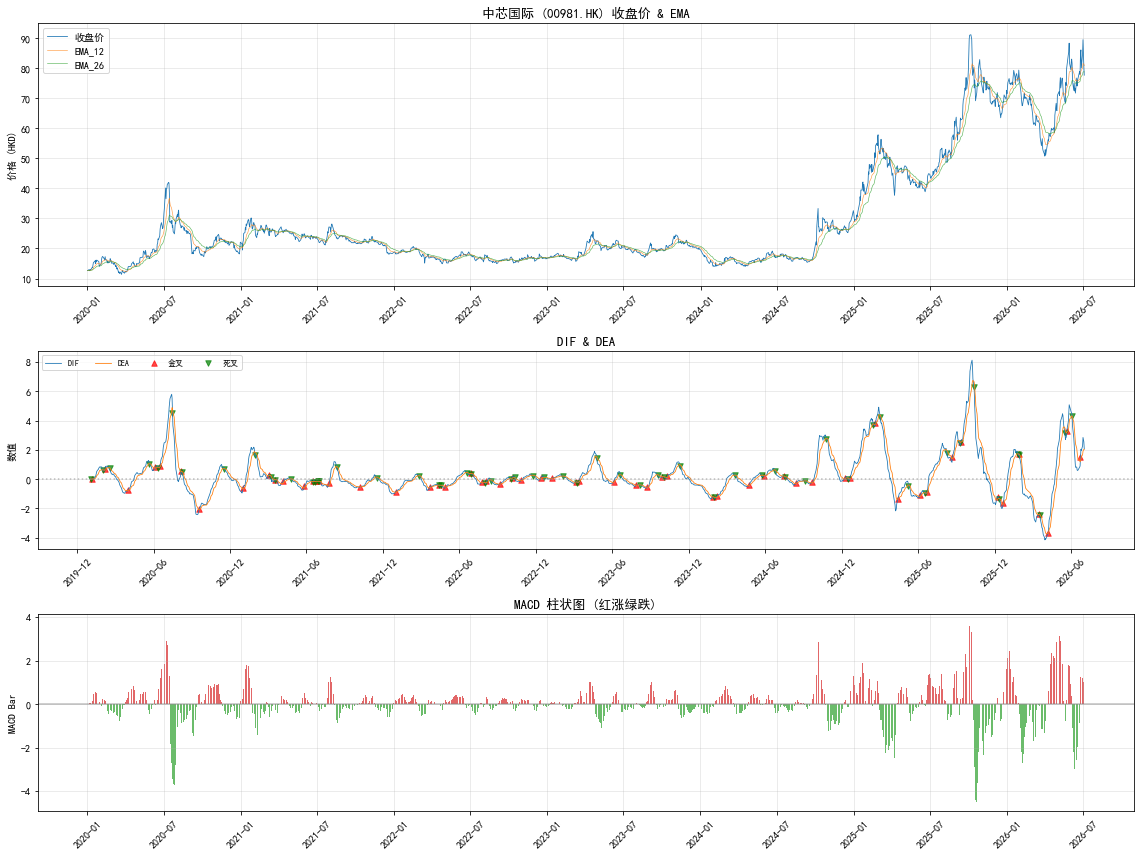

In [4]:
# MACD 参数
FAST = 12
SLOW = 26
SIGNAL = 9

# Step 1 & 2: 计算 EMA
df['ema_12'] = df['close'].ewm(span=FAST, adjust=False).mean()
df['ema_26'] = df['close'].ewm(span=SLOW, adjust=False).mean()

# Step 3: DIF
df['dif'] = df['ema_12'] - df['ema_26']

# Step 4: DEA
df['dea'] = df['dif'].ewm(span=SIGNAL, adjust=False).mean()

# Step 5: MACD 柱状图
df['macd_bar'] = 2 * (df['dif'] - df['dea'])

# 展示中间结果
print('=== MACD 计算中间结果（第26-55行）===')
display(df[['trade_date', 'close', 'ema_12', 'ema_26', 'dif', 'dea', 'macd_bar']].iloc[SLOW:SLOW+30].round(4))

# 找金叉/死叉
df['dif_dea_diff'] = df['dif'] - df['dea']
df['signal'] = 0
for i in range(1, len(df)):
    if df.loc[df.index[i], 'dif_dea_diff'] > 0 and df.loc[df.index[i-1], 'dif_dea_diff'] <= 0:
        df.loc[df.index[i], 'signal'] = 1  # 金叉
    elif df.loc[df.index[i], 'dif_dea_diff'] < 0 and df.loc[df.index[i-1], 'dif_dea_diff'] >= 0:
        df.loc[df.index[i], 'signal'] = -1  # 死叉

golden_cross = df[df['signal'] == 1][['trade_date', 'close']].head(10)
dead_cross = df[df['signal'] == -1][['trade_date', 'close']].head(10)
print(f'\n金叉次数: {(df["signal"] == 1).sum()}')
print(f'死叉次数: {(df["signal"] == -1).sum()}')
print('\n最近10次金叉:')
display(golden_cross)

# MACD 可视化
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [2, 1.5, 1.5]})

# 面板1: 收盘价 + EMA
ax1.plot(df['trade_date'], df['close'], color='#1f77b4', linewidth=0.8, label='收盘价')
ax1.plot(df['trade_date'], df['ema_12'], color='#ff7f0e', linewidth=0.6, alpha=0.8, label='EMA_12')
ax1.plot(df['trade_date'], df['ema_26'], color='#2ca02c', linewidth=0.6, alpha=0.8, label='EMA_26')
ax1.set_title('中芯国际 (00981.HK) 收盘价 & EMA', fontsize=13, fontweight='bold')
ax1.set_ylabel('价格 (HKD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 面板2: DIF + DEA
ax2.plot(df['trade_date'], df['dif'], color='#1f77b4', linewidth=0.8, label='DIF')
ax2.plot(df['trade_date'], df['dea'], color='#ff7f0e', linewidth=0.8, label='DEA')
ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
# 标注金叉死叉
golden = df[df['signal'] == 1]
dead = df[df['signal'] == -1]
ax2.scatter(golden['trade_date'], golden['dif'], color='red', marker='^', s=30, alpha=0.7, label='金叉')
ax2.scatter(dead['trade_date'], dead['dif'], color='green', marker='v', s=30, alpha=0.7, label='死叉')
ax2.set_title('DIF & DEA', fontsize=13, fontweight='bold')
ax2.set_ylabel('数值')
ax2.legend(loc='upper left', ncol=4, fontsize=8)
ax2.grid(True, alpha=0.3)

# 面板3: MACD 柱状图
colors = ['#d62728' if v >= 0 else '#2ca02c' for v in df['macd_bar']]
ax3.bar(df['trade_date'], df['macd_bar'], color=colors, width=1, alpha=0.7)
ax3.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax3.set_title('MACD 柱状图 (红涨绿跌)', fontsize=13, fontweight='bold')
ax3.set_ylabel('MACD Bar')
ax3.grid(True, alpha=0.3)

for ax in [ax1, ax2, ax3]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## Cell 5: 布林带 — 计算与可视化

### 计算步骤
1. 计算中轨 MID = 20 日简单移动平均 (SMA)
2. 计算 20 日滚动标准差 σ
3. 计算上轨 UPPER = MID + 2 × σ
4. 计算下轨 LOWER = MID - 2 × σ
5. 计算带宽 = (UPPER - LOWER) / MID × 100%

=== 布林带计算中间结果（第20-44行）===


,trade_date,close,bb_mid,bb_std,bb_upper,bb_lower,bb_width
20,2020-02-03,14.72,14.337,1.2418,16.8205,11.8535,34.6447
21,2020-02-04,15.48,14.479,1.1991,16.8773,12.0807,33.1274
22,2020-02-05,16.80,14.667,1.2551,17.1772,12.1568,34.2290
23,2020-02-06,17.18,14.896,1.2758,17.4475,12.3445,34.2578
24,2020-02-07,17.36,15.128,1.2811,17.6902,12.5658,33.8738
25,2020-02-10,16.76,15.316,1.2271,17.7703,12.8617,32.0486
26,2020-02-11,16.46,15.491,1.1182,17.7274,13.2546,28.8736
27,2020-02-12,16.22,15.618,1.0434,17.7049,13.5311,26.7239
28,2020-02-13,17.28,15.800,0.9967,17.7933,13.8067,25.2321
29,2020-02-14,16.26,15.893,0.9446,17.7822,14.0038,23.7734



收盘价突破上轨次数: 127
收盘价跌破下轨次数: 74
当前带宽: 25.49%


D:\Anaconda\lib\site-packages\matplotlib\cbook\__init__.py:2064: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
D:\Anaconda\lib\site-packages\matplotlib\axes\_base.py:248: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
D:\Anaconda\lib\site-packages\matplotlib\axes\_base.py:250: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


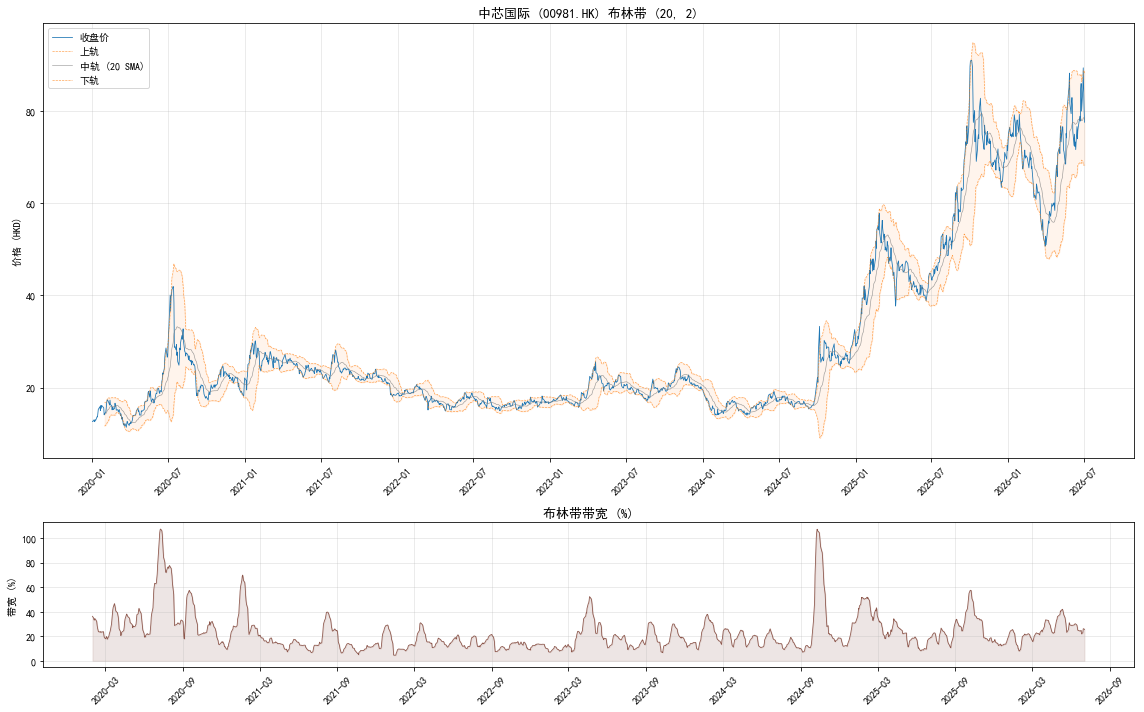

In [5]:
# 布林带参数
BB_PERIOD = 20
BB_STD = 2

# Step 1: 中轨 (20日 SMA)
df['bb_mid'] = df['close'].rolling(window=BB_PERIOD).mean()

# Step 2: 滚动标准差
df['bb_std'] = df['close'].rolling(window=BB_PERIOD).std()

# Step 3 & 4: 上下轨
df['bb_upper'] = df['bb_mid'] + BB_STD * df['bb_std']
df['bb_lower'] = df['bb_mid'] - BB_STD * df['bb_std']

# Step 5: 带宽
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['bb_mid'] * 100

# 展示中间结果
print('=== 布林带计算中间结果（第20-44行）===')
display(df[['trade_date', 'close', 'bb_mid', 'bb_std', 'bb_upper', 'bb_lower', 'bb_width']].iloc[BB_PERIOD:BB_PERIOD+25].round(4))

# 统计突破
above_upper = (df['close'] > df['bb_upper']).sum()
below_lower = (df['close'] < df['bb_lower']).sum()
print(f'\n收盘价突破上轨次数: {above_upper}')
print(f'收盘价跌破下轨次数: {below_lower}')
print(f'当前带宽: {df["bb_width"].iloc[-1]:.2f}%')

# 布林带可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(df['trade_date'], df['close'], color='#1f77b4', linewidth=0.8, label='收盘价')
ax1.plot(df['trade_date'], df['bb_upper'], color='#ff7f0e', linestyle='--', linewidth=0.6, alpha=0.8, label='上轨')
ax1.plot(df['trade_date'], df['bb_mid'], color='#7f7f7f', linewidth=0.6, alpha=0.8, label='中轨 (20 SMA)')
ax1.plot(df['trade_date'], df['bb_lower'], color='#ff7f0e', linestyle='--', linewidth=0.6, alpha=0.8, label='下轨')
ax1.fill_between(df['trade_date'], df['bb_upper'], df['bb_lower'], alpha=0.08, color='#ff7f0e')
ax1.set_title('中芯国际 (00981.HK) 布林带 (20, 2)', fontsize=13, fontweight='bold')
ax1.set_ylabel('价格 (HKD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.plot(df['trade_date'], df['bb_width'], color='#8c564b', linewidth=0.8)
ax2.fill_between(df['trade_date'], df['bb_width'], alpha=0.15, color='#8c564b')
ax2.set_title('布林带带宽 (%)', fontsize=13, fontweight='bold')
ax2.set_ylabel('带宽 (%)')
ax2.grid(True, alpha=0.3)

for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## Cell 6: ATR 指标 — 计算与可视化

### 计算步骤
1. 计算每日真实波幅 TR = max(High-Low, |High-Close[t-1]|, |Low-Close[t-1]|)
2. 计算 ATR = TR 的 14 日 Wilder 平滑平均

=== ATR 计算中间结果（前20行有效数据）===


,trade_date,high,low,prev_close,tr_h_l,tr_h_pc,tr_l_pc,tr,atr
14,2020-01-22,16.20,14.92,15.00,1.28,1.20,0.08,1.28,0.7286
15,2020-01-23,16.44,14.90,16.10,1.54,0.34,1.20,1.54,0.7865
16,2020-01-24,16.20,15.16,15.50,1.04,0.70,0.34,1.04,0.8046
17,2020-01-29,16.06,15.34,16.14,0.72,0.08,0.80,0.80,0.8043
18,2020-01-30,15.82,13.80,15.62,2.02,0.20,1.82,2.02,0.8911
19,2020-01-31,14.74,14.14,14.08,0.60,0.66,0.06,0.66,0.8746
20,2020-02-03,15.10,13.60,14.30,1.50,0.80,0.70,1.50,0.9193
21,2020-02-04,15.64,15.00,14.72,0.64,0.92,0.28,0.92,0.9193
22,2020-02-05,16.82,15.46,15.48,1.36,1.34,0.02,1.36,0.9508
23,2020-02-06,17.52,16.52,16.80,1.00,0.72,0.28,1.00,0.9543



当前 ATR(14): 6.2094
当前收盘价: 77.60
ATR/收盘价: 8.00%
含义: 日均波动幅度约为当前价格的 8.00%


D:\Anaconda\lib\site-packages\matplotlib\cbook\__init__.py:2064: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
D:\Anaconda\lib\site-packages\matplotlib\axes\_base.py:248: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
D:\Anaconda\lib\site-packages\matplotlib\axes\_base.py:250: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


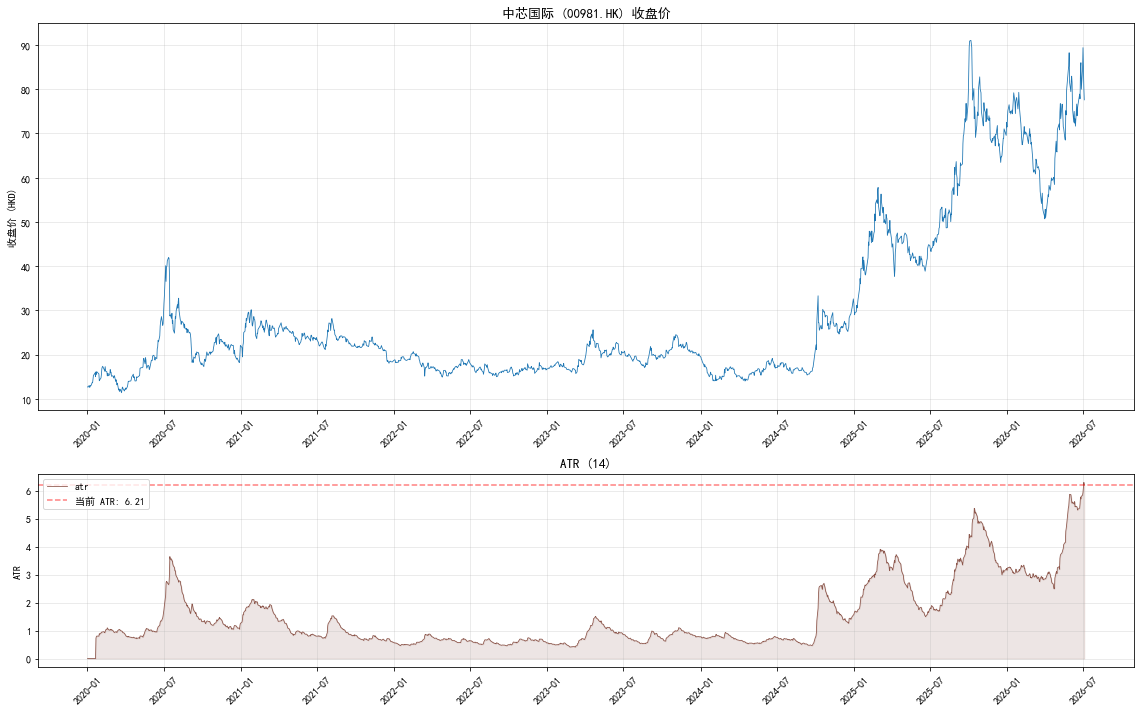

In [6]:
# ATR 参数
ATR_PERIOD = 14

# Step 1: 计算 True Range
df['prev_close'] = df['close'].shift(1)
df['tr_h_l'] = df['high'] - df['low']
df['tr_h_pc'] = np.abs(df['high'] - df['prev_close'])
df['tr_l_pc'] = np.abs(df['low'] - df['prev_close'])
df['tr'] = df[['tr_h_l', 'tr_h_pc', 'tr_l_pc']].max(axis=1)

# Step 2: Wilder 平滑法计算 ATR
df['atr'] = 0.0
first_atr = df['tr'].iloc[1:ATR_PERIOD+1].mean()
df.loc[df.index[ATR_PERIOD], 'atr'] = first_atr
for i in range(ATR_PERIOD + 1, len(df)):
    df.loc[df.index[i], 'atr'] = (df.loc[df.index[i-1], 'atr'] * (ATR_PERIOD - 1) + df.loc[df.index[i], 'tr']) / ATR_PERIOD

# 展示中间结果
print('=== ATR 计算中间结果（前20行有效数据）===')
display(df[['trade_date', 'high', 'low', 'prev_close', 'tr_h_l', 'tr_h_pc', 'tr_l_pc', 'tr', 'atr']].iloc[ATR_PERIOD:ATR_PERIOD+20].round(4))

current_atr = df['atr'].iloc[-1]
current_close = df['close'].iloc[-1]
atr_pct = current_atr / current_close * 100
print(f'\n当前 ATR(14): {current_atr:.4f}')
print(f'当前收盘价: {current_close:.2f}')
print(f'ATR/收盘价: {atr_pct:.2f}%')
print(f'含义: 日均波动幅度约为当前价格的 {atr_pct:.2f}%')

# ATR 可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(df['trade_date'], df['close'], color='#1f77b4', linewidth=0.8)
ax1.set_title('中芯国际 (00981.HK) 收盘价', fontsize=13, fontweight='bold')
ax1.set_ylabel('收盘价 (HKD)')
ax1.grid(True, alpha=0.3)

ax2.plot(df['trade_date'], df['atr'], color='#8c564b', linewidth=0.8)
ax2.fill_between(df['trade_date'], df['atr'], alpha=0.15, color='#8c564b')
ax2.axhline(y=current_atr, color='red', linestyle='--', alpha=0.5, label=f'当前 ATR: {current_atr:.2f}')
ax2.set_title('ATR (14)', fontsize=13, fontweight='bold')
ax2.set_ylabel('ATR')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## Cell 7: 四指标综合展示

将四个技术指标放在一张综合仪表盘中，展示多维度的技术分析视角。

D:\Anaconda\lib\site-packages\matplotlib\cbook\__init__.py:2064: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
D:\Anaconda\lib\site-packages\matplotlib\axes\_base.py:248: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
D:\Anaconda\lib\site-packages\matplotlib\axes\_base.py:250: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


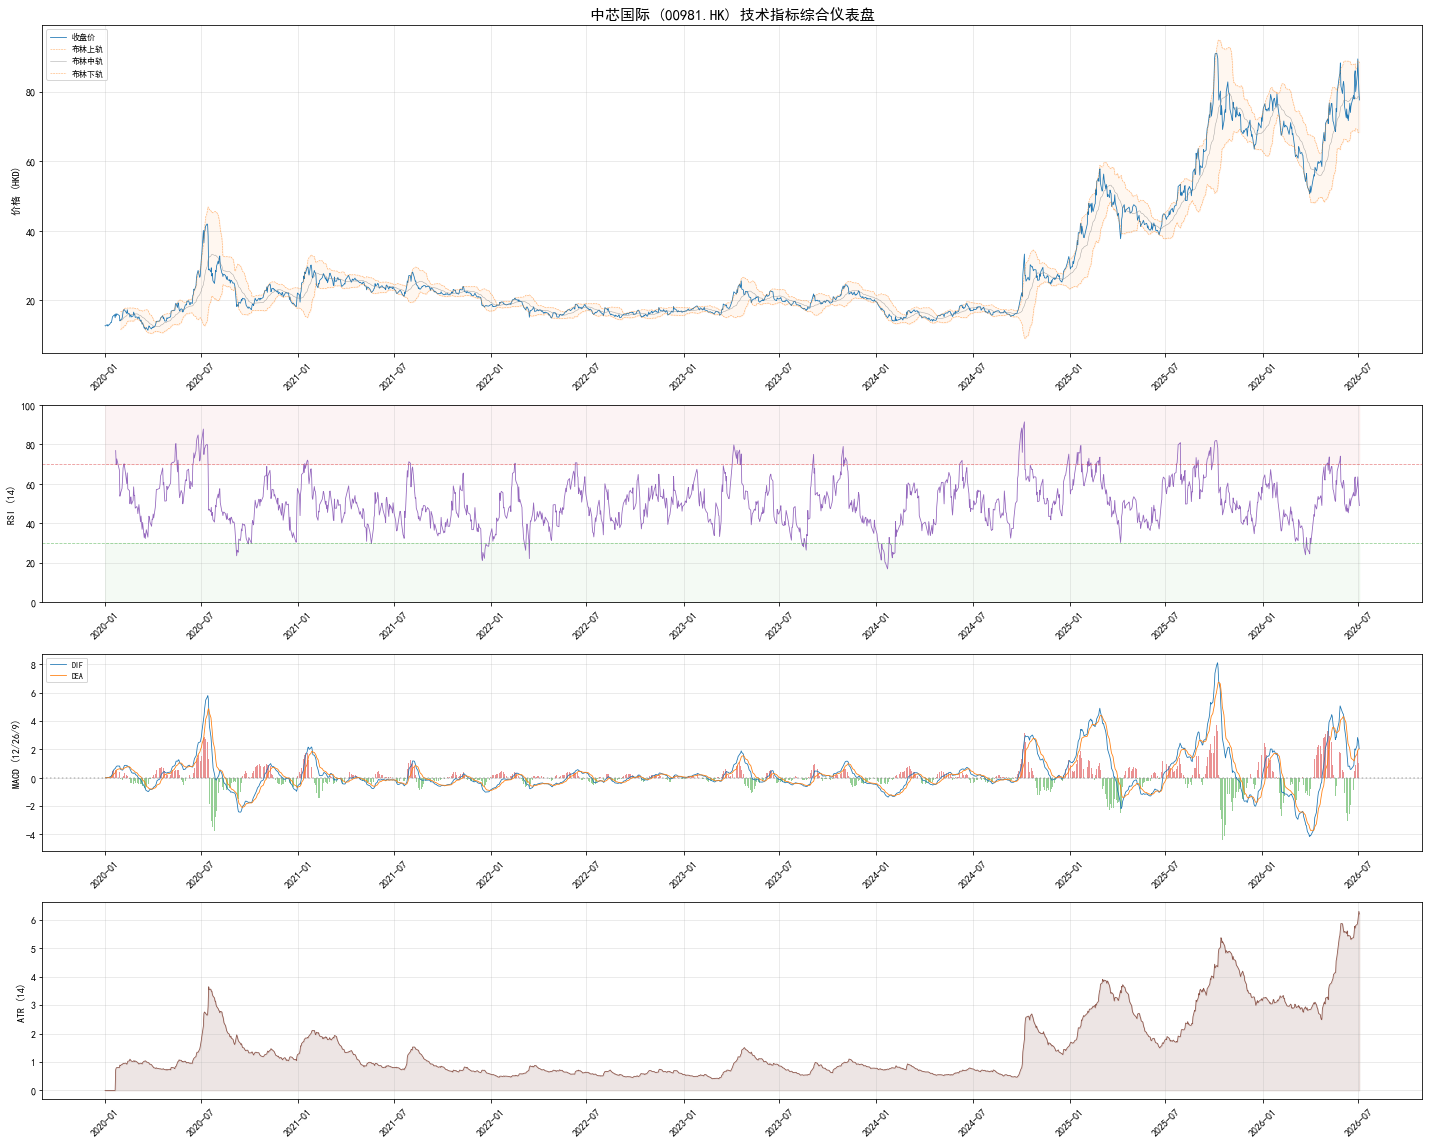

In [7]:
# 综合仪表盘
fig, axes = plt.subplots(4, 1, figsize=(20, 16), gridspec_kw={'height_ratios': [2.5, 1.5, 1.5, 1.5]})
ax1, ax2, ax3, ax4 = axes

# 面板1: 收盘价 + 布林带
ax1.plot(df['trade_date'], df['close'], color='#1f77b4', linewidth=0.8, label='收盘价')
ax1.plot(df['trade_date'], df['bb_upper'], color='#ff7f0e', linestyle='--', linewidth=0.5, alpha=0.7, label='布林上轨')
ax1.plot(df['trade_date'], df['bb_mid'], color='#7f7f7f', linewidth=0.5, alpha=0.7, label='布林中轨')
ax1.plot(df['trade_date'], df['bb_lower'], color='#ff7f0e', linestyle='--', linewidth=0.5, alpha=0.7, label='布林下轨')
ax1.fill_between(df['trade_date'], df['bb_upper'], df['bb_lower'], alpha=0.06, color='#ff7f0e')
ax1.set_title('中芯国际 (00981.HK) 技术指标综合仪表盘', fontsize=15, fontweight='bold')
ax1.set_ylabel('价格 (HKD)')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# 面板2: RSI
ax2.plot(df['trade_date'], df['rsi'], color='#9467bd', linewidth=0.8)
ax2.axhline(y=70, color='#d62728', linestyle='--', alpha=0.5, linewidth=0.8)
ax2.axhline(y=30, color='#2ca02c', linestyle='--', alpha=0.5, linewidth=0.8)
ax2.fill_between(df['trade_date'], 70, 100, alpha=0.05, color='#d62728')
ax2.fill_between(df['trade_date'], 0, 30, alpha=0.05, color='#2ca02c')
ax2.set_ylim(0, 100)
ax2.set_ylabel('RSI (14)')
ax2.grid(True, alpha=0.3)

# 面板3: MACD
ax3.plot(df['trade_date'], df['dif'], color='#1f77b4', linewidth=0.8, label='DIF')
ax3.plot(df['trade_date'], df['dea'], color='#ff7f0e', linewidth=0.8, label='DEA')
bar_colors = ['#d62728' if v >= 0 else '#2ca02c' for v in df['macd_bar']]
ax3.bar(df['trade_date'], df['macd_bar'], color=bar_colors, width=1, alpha=0.5)
ax3.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax3.set_ylabel('MACD (12/26/9)')
ax3.legend(loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)

# 面板4: ATR
ax4.plot(df['trade_date'], df['atr'], color='#8c564b', linewidth=0.8)
ax4.fill_between(df['trade_date'], df['atr'], alpha=0.15, color='#8c564b')
ax4.set_ylabel('ATR (14)')
ax4.grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## Cell 8: 总结与解读

In [8]:
# 当前最新指标汇总
latest = df.iloc[-1]
print('=' * 60)
print(f'  中芯国际 (00981.HK) 技术指标分析报告')
print(f'  日期: {latest["trade_date"].strftime("%Y-%m-%d")}')
print('=' * 60)

summary_data = {
    '指标': ['收盘价', 'RSI(14)', 'MACD DIF', 'MACD DEA', 'MACD 柱', '布林上轨', '布林中轨', '布林下轨', 'ATR(14)'],
    '数值': [
        f'{latest["close"]:.2f}',
        f'{latest["rsi"]:.2f}',
        f'{latest["dif"]:.4f}',
        f'{latest["dea"]:.4f}',
        f'{latest["macd_bar"]:.4f}',
        f'{latest["bb_upper"]:.2f}',
        f'{latest["bb_mid"]:.2f}',
        f'{latest["bb_lower"]:.2f}',
        f'{latest["atr"]:.4f}',
    ],
}
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print('\n' + '=' * 60)
print('  各指标信号解读')
print('=' * 60)

# RSI 解读
rsi = latest['rsi']
if rsi > 70:
    rsi_signal = '⚠ 超买 — 价格可能回调，短期偏空'
elif rsi < 30:
    rsi_signal = '⚠ 超卖 — 价格可能反弹，短期偏多'
elif rsi > 50:
    rsi_signal = '↗ 偏强 — 多头占优'
else:
    rsi_signal = '↘ 偏弱 — 空头占优'
print(f'\nRSI(14): {rsi:.2f} → {rsi_signal}')

# MACD 解读
dif, dea, bar = latest['dif'], latest['dea'], latest['macd_bar']
if dif > dea and bar > 0:
    macd_signal = '↗ 多头排列 — DIF > DEA，柱状图为正，趋势偏多'
elif dif < dea and bar < 0:
    macd_signal = '↘ 空头排列 — DIF < DEA，柱状图为负，趋势偏空'
elif dif > dea:
    macd_signal = '→ DIF 上穿 DEA，但柱状图收窄，关注动能变化'
else:
    macd_signal = '→ DIF 下穿 DEA，空头信号'
print(f'MACD: DIF={dif:.4f}, DEA={dea:.4f}, Bar={bar:.4f} → {macd_signal}')

# 布林带解读
close = latest['close']
upper, mid, lower = latest['bb_upper'], latest['bb_mid'], latest['bb_lower']
if close > upper:
    bb_signal = '⚠ 价格突破上轨 — 可能超买，关注回调风险'
elif close < lower:
    bb_signal = '⚠ 价格跌破下轨 — 可能超卖，关注反弹机会'
elif close > mid:
    bb_signal = '↗ 价格在中轨上方 — 短期偏强'
else:
    bb_signal = '↘ 价格在中轨下方 — 短期偏弱'
width = latest['bb_width']
print(f'布林带: 收盘={close:.2f}, 上轨={upper:.2f}, 中轨={mid:.2f}, 下轨={lower:.2f}')
print(f'        带宽={width:.2f}% → {bb_signal}')

# ATR 解读
atr = latest['atr']
print(f'ATR(14): {atr:.4f} (占收盘价 {atr/close*100:.2f}%) → 日均真实波动约 {atr:.2f} HKD')

print('\n' + '=' * 60)
print('  综合研判')
print('=' * 60)

bullish = 0
bearish = 0
if rsi > 50: bullish += 1
else: bearish += 1
if dif > dea: bullish += 1
else: bearish += 1
if close > mid: bullish += 1
else: bearish += 1

print(f'多头信号: {bullish}/3, 空头信号: {bearish}/3')
if bullish >= 2:
    print('综合判断: 偏多 — 多数指标指向多头，但需注意 RSI 是否超买')
elif bearish >= 2:
    print('综合判断: 偏空 — 多数指标指向空头，但需注意 RSI 是否超卖')
else:
    print('综合判断: 震荡 — 多空信号不一致，建议观望')

print('\n' + '=' * 60)
print('  注意事项')
print('=' * 60)
print('1. 技术指标基于历史价格计算，不预测未来走势')
print('2. 单一指标信号可能存在误导，应结合多个指标综合判断')
print('3. 港股市场受政策、流动性、国际市场等多重因素影响')
print('4. 建议结合基本面分析和市场情绪综合决策')
print('5. 本报告仅供参考，不构成投资建议')

  中芯国际 (00981.HK) 技术指标分析报告
  日期: 2026-07-03
       指标      数值
      收盘价   77.60
  RSI(14)   48.97
 MACD DIF  2.0619
 MACD DEA  2.0361
   MACD 柱  0.0517
     布林上轨   88.20
     布林中轨   78.23
     布林下轨   68.26
  ATR(14)  6.2094

  各指标信号解读

RSI(14): 48.97 → ↘ 偏弱 — 空头占优
MACD: DIF=2.0619, DEA=2.0361, Bar=0.0517 → ↗ 多头排列 — DIF > DEA，柱状图为正，趋势偏多
布林带: 收盘=77.60, 上轨=88.20, 中轨=78.23, 下轨=68.26
        带宽=25.49% → ↘ 价格在中轨下方 — 短期偏弱
ATR(14): 6.2094 (占收盘价 8.00%) → 日均真实波动约 6.21 HKD

  综合研判
多头信号: 1/3, 空头信号: 2/3
综合判断: 偏空 — 多数指标指向空头，但需注意 RSI 是否超卖

  注意事项
1. 技术指标基于历史价格计算，不预测未来走势
2. 单一指标信号可能存在误导，应结合多个指标综合判断
3. 港股市场受政策、流动性、国际市场等多重因素影响
4. 建议结合基本面分析和市场情绪综合决策
5. 本报告仅供参考，不构成投资建议
